In [1]:
from statsmodels.tsa.stattools import adfuller

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

In [3]:
project_dir = Path.cwd().parent

In [ ]:
project_dir

In [4]:
df = pd.read_csv(project_dir/"data"/"hourly_demand.csv", index_col=0, parse_dates=True)

In [ ]:
df

In [5]:
import yaml

In [6]:
yaml_path = project_dir/'config.yaml'

In [7]:
with open(yaml_path, "r") as file:
    config = yaml.safe_load(file)

In [8]:
df

,Trips
tpep_pickup_datetime,
2024-12-31 20:00:00,2
2024-12-31 21:00:00,0
2024-12-31 22:00:00,0
2024-12-31 23:00:00,0
2025-01-01 00:00:00,727
...,...
2026-05-31 19:00:00,633
2026-05-31 20:00:00,533
2026-05-31 21:00:00,509


In [9]:
df.sort_index(inplace=True)

In [10]:
idx = int(len(df)*0.8)

In [11]:
train = df.iloc[:idx]
test = df.iloc[idx:]

In [12]:
import pmdarima

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score,root_mean_squared_error
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

In [15]:
model = pmdarima.auto_arima(
    test,
    seasonal=True,
    m=24,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    d=1, D=1,
    stepwise=True,
    approximation=True,
    n_jobs=1,
    trace=True,
    maxiter=30
)

Performing stepwise search to minimize aic
 ARIMA(0,1,0)(0,1,0)[24]             : AIC=29161.817, Time=0.26 sec
 ARIMA(1,1,0)(1,1,0)[24]             : AIC=28990.292, Time=2.30 sec
 ARIMA(0,1,1)(0,1,1)[24]             : AIC=inf, Time=15.94 sec
 ARIMA(1,1,0)(0,1,0)[24]             : AIC=29143.018, Time=0.25 sec
 ARIMA(1,1,0)(2,1,0)[24]             : AIC=28900.220, Time=6.65 sec
 ARIMA(1,1,0)(2,1,1)[24]             : AIC=inf, Time=40.95 sec
 ARIMA(1,1,0)(1,1,1)[24]             : AIC=inf, Time=8.71 sec
 ARIMA(0,1,0)(2,1,0)[24]             : AIC=28958.808, Time=3.45 sec
 ARIMA(2,1,0)(2,1,0)[24]             : AIC=28898.803, Time=11.73 sec
 ARIMA(2,1,0)(1,1,0)[24]             : AIC=28990.561, Time=2.90 sec
 ARIMA(2,1,0)(2,1,1)[24]             : AIC=inf, Time=46.59 sec
 ARIMA(2,1,0)(1,1,1)[24]             : AIC=inf, Time=16.84 sec
 ARIMA(2,1,1)(2,1,0)[24]             : AIC=inf, Time=35.84 sec
 ARIMA(1,1,1)(2,1,0)[24]             : AIC=28900.150, Time=12.38 sec
 ARIMA(2,1,0)(2,1,0)[24] intercept

In [ ]:
#Best model:  ARIMA(1,1,0)(1,0,1)[24]

In [16]:
# Best model:  ARIMA(2,1,0)(2,1,0)[24]      2

In [17]:
# adf_test_1 = adfuller(hourly_demand)

In [ ]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(hourly_demand['Trips'], lags=40, ax=ax[0])
plot_pacf(hourly_demand['Trips'], lags=40, ax=ax[1])
plt.show()

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(hourly_demand['first_diff'], lags=40, ax=ax[0])
plot_pacf(hourly_demand['first_diff'], lags=40, ax=ax[1])
plt.show()

In [ ]:
config

In [ ]:
hourly_demand['Second_diff']=hourly_demand['first_diff'].diff()
hourly_demand.dropna(axis=0, inplace=True)

In [ ]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8))
plot_acf(hourly_demand['Second_diff'], lags=40, ax=ax[0])
plot_pacf(hourly_demand['Second_diff'], lags=40, ax=ax[1])
plt.show()

In [ ]:
hourly_demand.sort_index(inplace=True)

In [ ]:
hourly_demand

In [ ]:
idx = int(len(hourly_demand)*0.8)

In [ ]:
idx

In [ ]:
train = hourly_demand.iloc[:idx]
test = hourly_demand.iloc[idx:]


In [ ]:
train

In [ ]:
test

In [ ]:
config

In [ ]:
order = tuple(config["sarima"]["order"])
seasonal_order = tuple(config["sarima"]["seasonal_order"])


In [ ]:
new_order =(2, 1, 1)
new_seasonal_order =   (0, 1, 1, 24)

In [25]:
# Best model:  ARIMA
new_new_order =(2,1,0)
new_new_seasonal =  (2,1,0,24)

In [20]:
arima_model = ARIMA(train, order=new_new_order)

c:\Users\Shaaf\Desktop\Data Science\Practice Projects\Transport Planning\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\Shaaf\Desktop\Data Science\Practice Projects\Transport Planning\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\Shaaf\Desktop\Data Science\Practice Projects\Transport Planning\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [21]:
arima_results = arima_model.fit()

In [22]:
arima_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                  Trips   No. Observations:                 9910
Model:                 ARIMA(2, 1, 0)   Log Likelihood              -59458.430
Date:                Thu, 09 Jul 2026   AIC                         118922.860
Time:                        17:12:28   BIC                         118944.463
Sample:                    12-31-2024   HQIC                        118930.176
                         - 02-17-2026                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5990      0.007     90.948      0.000       0.586       0.612
ar.L2         -0.1147      0.008    -14.996      0.000      -0.130      -0.100
sigma2      9539.3644     83.315    114.498      0.000    9376.070    9702.659
===================================================================================
Ljung-Box (L1) (Q):                   1.47   Jarque-Bera (JB):              9962.16
Prob(Q):                              0.22   Prob(JB):                         0.00
Heteroskedasticity (H):               0.74   Skew:                            -0.52
Prob(H) (two-sided):                  0.00   Kurtosis:                         7.80
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

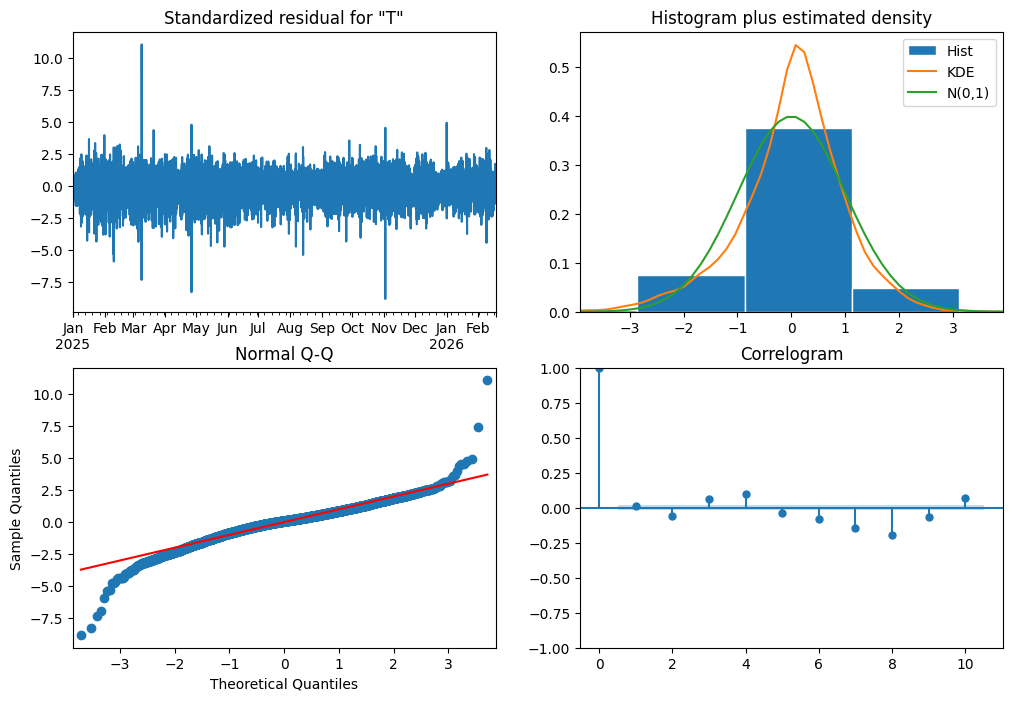

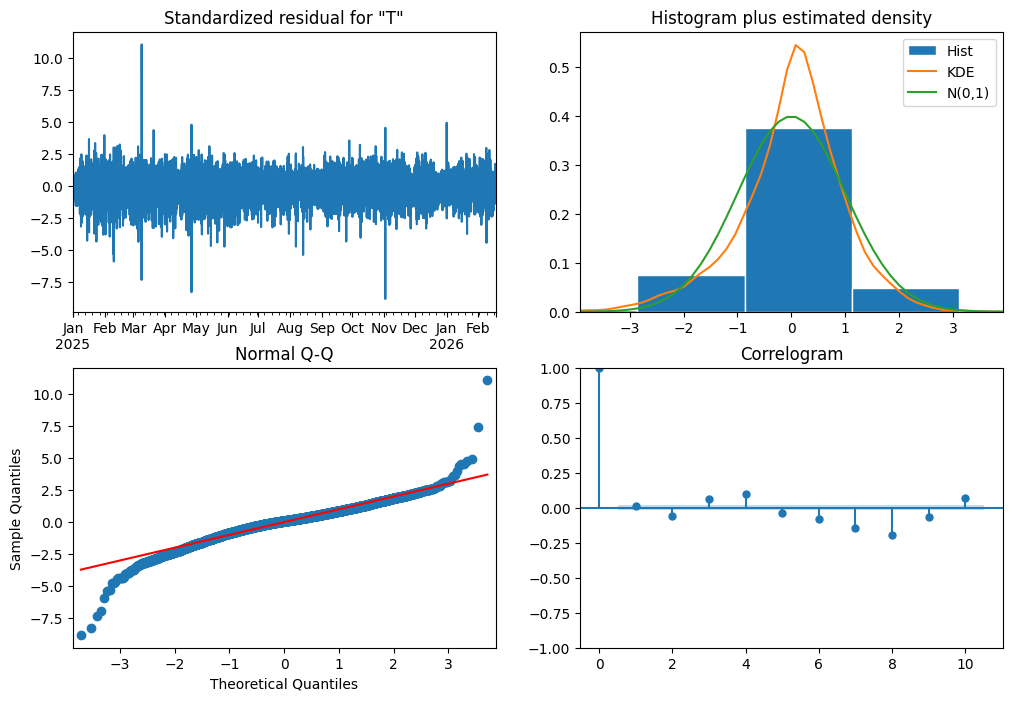

In [23]:
arima_results.plot_diagnostics(figsize=(12, 8))

In [ ]:
from statsmodels.stats.diagnostic import acorr_ljungbox

lb = acorr_ljungbox(
    arima_results.resid,
    lags=[24],
    return_df=True
)

print(lb)

In [26]:
sarima_model = SARIMAX(train, order=new_new_order, seasonal_order=new_new_seasonal)

c:\Users\Shaaf\Desktop\Data Science\Practice Projects\Transport Planning\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\Shaaf\Desktop\Data Science\Practice Projects\Transport Planning\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [27]:
sarima_results = sarima_model.fit()

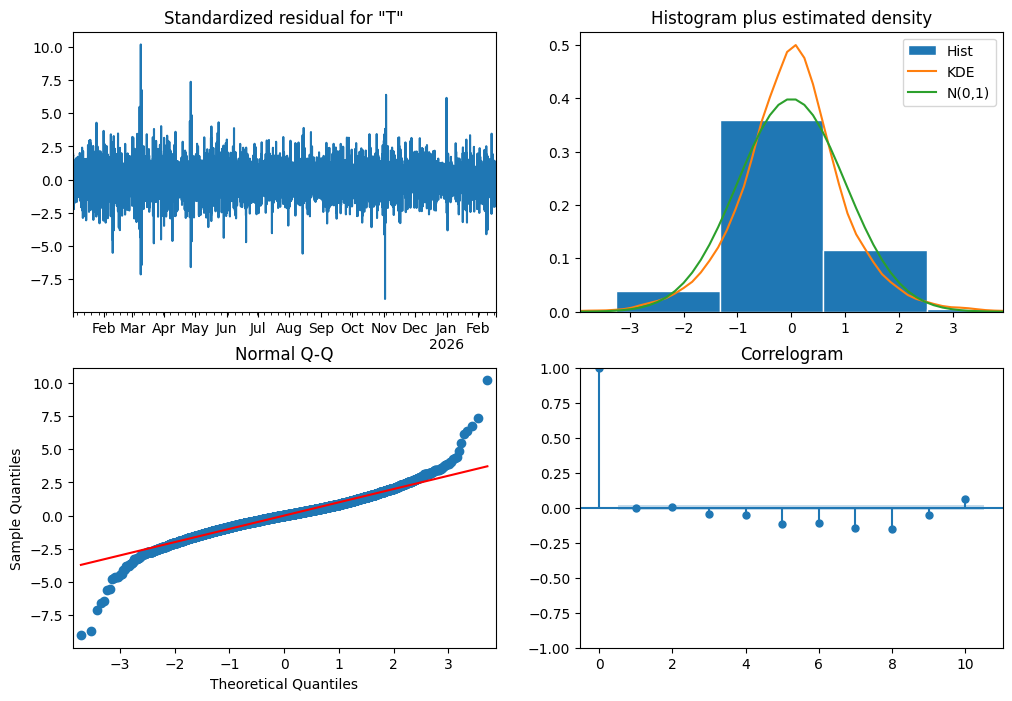

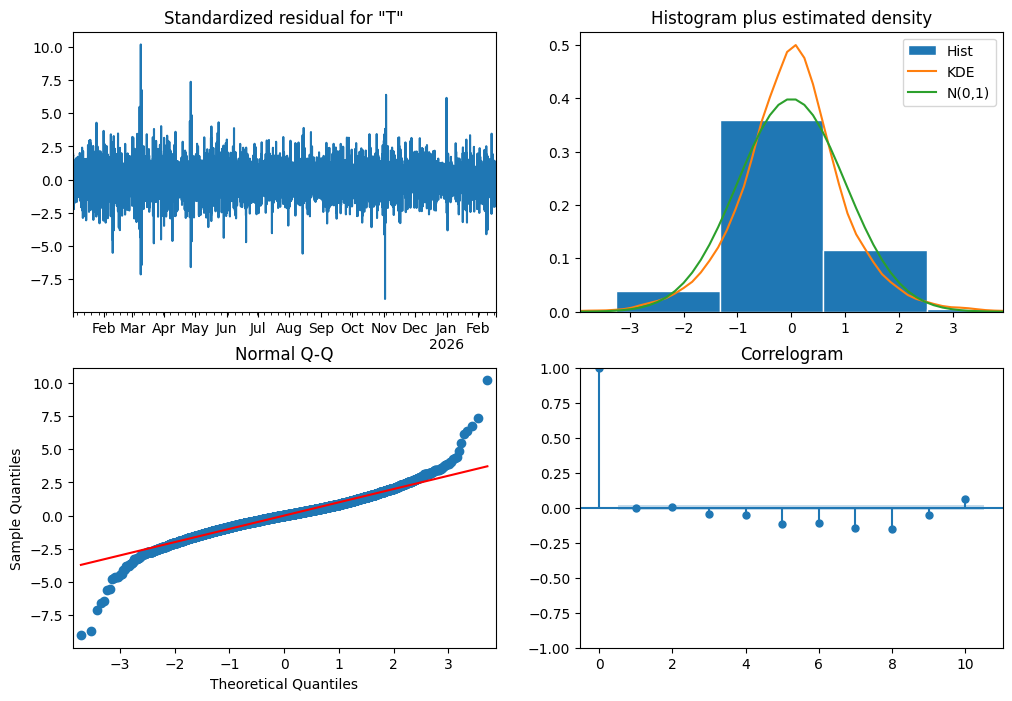

In [28]:
sarima_results.plot_diagnostics(figsize=(12, 8))

In [ ]:
lb_s = acorr_ljungbox(
    sarima_results.resid,
    lags=[24],
    return_df=True
)

print(lb_s)

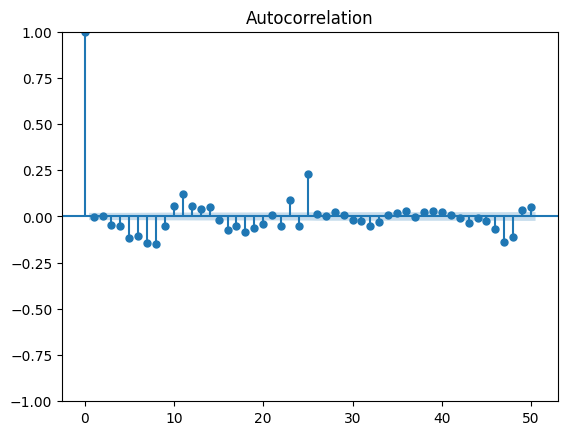

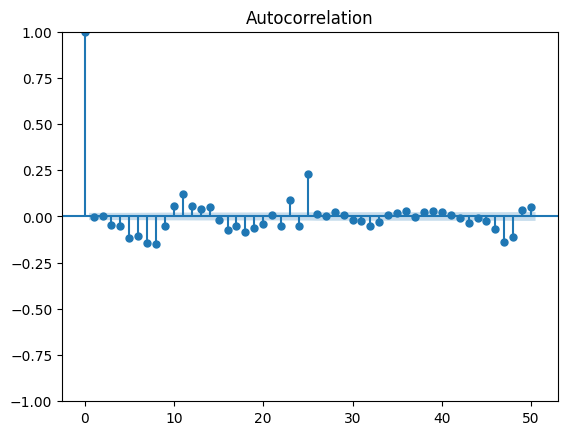

In [29]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(sarima_results.resid, lags=50)

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf

plot_pacf(sarima_results.resid, lags=50)

In [30]:
sarima_forecast = sarima_results.get_forecast(len(test))

In [31]:
arima_forecast = arima_results.get_forecast(len(test))

In [32]:
print(sarima_forecast)

In [33]:
arima_pred =arima_forecast.predicted_mean

In [34]:
sarima_pred = sarima_forecast.predicted_mean

In [35]:
test

,Trips
tpep_pickup_datetime,
2026-02-17 18:00:00,754
2026-02-17 19:00:00,660
2026-02-17 20:00:00,674
2026-02-17 21:00:00,683
2026-02-17 22:00:00,584
...,...
2026-05-31 19:00:00,633
2026-05-31 20:00:00,533
2026-05-31 21:00:00,509


In [36]:
conf = sarima_forecast.conf_int()

In [37]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

mae = mean_absolute_error(test, sarima_pred)

rmse = np.sqrt(
    mean_squared_error(test, sarima_pred)
)
mse = mean_squared_error(test,sarima_pred)
# mape = (
#     np.abs((test - pred) / test)
# ).mean() * 100

In [38]:
print(f"mae{mae}")
print(f"rmse{rmse}")
print(f"mse{mse}")
# print(f"mape{mape}")

mae2765.8657133789443
rmse3203.159377442551
mse10260229.99729815


In [39]:
ar_mae = mean_absolute_error(test, arima_pred)

ar_rmse = np.sqrt(
    mean_squared_error(test, arima_pred)
)
ar_mse = mean_squared_error(test,arima_pred)

In [40]:
# arima mae 340.7271762107078
# arima rmse426.5432708615953
# arima mse181939.1619173083

In [41]:
print(f"arima mae {ar_mae}")
print(f"arima rmse{ar_rmse}")
print(f"arima mse{ar_mse}")

arima mae 318.80164763332806
arima rmse404.08980798983333
arima mse163288.57292126035


In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.figure(figsize=(14,5))

plt.plot(train)

plt.plot(test)

plt.plot(pred)

plt.fill_between(
    conf.index,
    conf.iloc[:,0],
    conf.iloc[:,1],
    alpha=0.3
)

plt.legend()

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
season_results = seasonal_decompose(test, model='additive', period=24)

In [ ]:
season_results.plot()